In [33]:
import os
from pathlib import Path
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F


def _find_cnn_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data" / "ETHUSDT-1h-data.csv").is_file():
            return p
        cand = p / "CNN_ETH" / "data" / "ETHUSDT-1h-data.csv"
        if cand.is_file():
            return (p / "CNN_ETH").resolve()
    return here


CNN_ROOT = _find_cnn_root()
ARTIFACTS = CNN_ROOT / "artifacts"
DATA_CSV = CNN_ROOT / "data" / "ETHUSDT-1h-data.csv"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("ensemble_models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)



In [34]:
df = pd.read_csv(DATA_CSV)
print(df)


                 timestamp     open     high      low    close       volume
0      2018-05-15 19:00:00   712.87   716.19   705.00   713.77   4761.58231
1      2018-05-15 20:00:00   713.55   715.39   708.82   711.10   2739.48414
2      2018-05-15 21:00:00   711.82   713.14   707.60   708.25   2964.06867
3      2018-05-15 22:00:00   708.61   711.24   695.00   699.67   6599.59027
4      2018-05-15 23:00:00   700.28   709.49   698.29   704.91   4101.62903
...                    ...      ...      ...      ...      ...          ...
68995  2026-04-02 06:00:00  2050.21  2053.71  2045.56  2050.09  11368.96200
68996  2026-04-02 07:00:00  2050.09  2056.76  2044.29  2056.09  10318.06670
68997  2026-04-02 08:00:00  2056.09  2056.09  2045.36  2046.29   7587.72130
68998  2026-04-02 09:00:00  2046.30  2048.14  2039.27  2044.00   9339.01910
68999  2026-04-02 10:00:00  2044.00  2045.05  2032.54  2037.87   7530.69950

[69000 rows x 6 columns]


**Check missing values**

In [35]:
print(df.isnull())
print(f"Counts how many missing values there are in each column: {df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

       timestamp   open   high    low  close  volume
0          False  False  False  False  False   False
1          False  False  False  False  False   False
2          False  False  False  False  False   False
3          False  False  False  False  False   False
4          False  False  False  False  False   False
...          ...    ...    ...    ...    ...     ...
68995      False  False  False  False  False   False
68996      False  False  False  False  False   False
68997      False  False  False  False  False   False
68998      False  False  False  False  False   False
68999      False  False  False  False  False   False

[69000 rows x 6 columns]
Counts how many missing values there are in each column: timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64
Total missing values: 0


**Split data**

In [36]:
import json

with open(ARTIFACTS / "split_info.json", "r", encoding="utf-8") as f:
    sp = json.load(f)
train_end = int(sp["train_end"])
val_end = int(sp["val_end"])
total_rows = int(sp.get("total_rows", len(df)))

with open(ARTIFACTS / "scalers.pkl", "rb") as f:
    train_scalers = pickle.load(f)

df_sel = df.iloc[train_end:val_end].copy()
df_hold = df.iloc[val_end:total_rows].copy()

print(f"Selection (test) slice [{train_end}:{val_end}] len={len(df_sel)}")
print(f"Holdout (backtest) slice [{val_end}:{total_rows}] len={len(df_hold)}")


Selection (test) slice [61500:63000] len=1500
Holdout (backtest) slice [63000:69000] len=6000


**Building Meaningful Features**

In [37]:
def build_features(opens, highs, lows, closes, volumes, train_scalers=None):

    # Build features
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    # Stack features
    features = [
        feature1,
        feature2,
        feature3,
        feature4,
        feature5,
        feature6,
        feature7,
        feature8,
    ]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        # Get train scaler
        scaler = train_scalers[i]
        if is_train:
            # Scaler -> Fit -> Train dataset
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
            # Save the train scaler in a list
        elif not is_train:
            # Scaler -> NOT Fit -> Test dataset
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))

        # Update list of SCALED features
        scaled_fts.append(scaled_ft.flatten())

    # Stack features
    scaled_features = np.stack(scaled_fts, axis=-1)

    # Get num. features
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers

**Preprocess data**

In [38]:
def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)

    opens = np.array(df['open'].values)
    highs = np.array(df['high'].values)
    lows = np.array(df['low'].values)
    closes = np.array(df['close'].values)
    volumes = np.array(df['volume'].values)

    # Build features
    features, num_features, train_scalers = build_features(opens, highs, lows, closes, volumes, train_scalers)

    # Calculate number of samples
    num_samples = m - seq_len

    # Create storage for inputs & targets
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    # Create samples (X, Y)
    for i in range(num_samples):
        X[i] = features[i : i+seq_len]
        Y[i] = features[i+seq_len : i+seq_len+1]

    # Fix alignment
    opens = np.array(opens[seq_len:])
    highs = np.array(highs[seq_len:])
    lows = np.array(lows[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, highs, lows, closes, train_scalers

In [39]:
# Sequence Length
seq_len = 48

# Transform only — scalers loaded from artifacts (no fit on post-train rows)
X_sel, Y_sel, num_features, sel_opens, sel_highs, sel_lows, sel_closes, _ = preprocess_data(
    seq_len, df_sel, train_scalers
)
X_hold, Y_hold, num_features, ho_opens, ho_highs, ho_lows, ho_closes, _ = preprocess_data(
    seq_len, df_hold, train_scalers
)



In [40]:
m_sel = X_sel.shape[0]
m_hold = X_hold.shape[0]
print(f"m_sel: {m_sel}")
print(f"m_hold: {m_hold}")
print(f"X_sel shape: {X_sel.shape}")
print(f"X_hold shape: {X_hold.shape}")
print(f"num_features: {num_features}")


m_sel: 1452
m_hold: 5952
X_sel shape: (1452, 48, 8)
X_hold shape: (5952, 48, 8)
num_features: 8


**Transform data to Torch Tensor**

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("my device: ", device)

X_sel_t = torch.from_numpy(X_sel.astype(np.float32)).to(device, dtype=torch.float32)
X_hold_t = torch.from_numpy(X_hold.astype(np.float32)).to(device, dtype=torch.float32)



my device:  cuda:0


**Build model**

In [42]:
class Model_1(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1 block #1
        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=32,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.act1 = nn.GELU()

        # Conv1 block #2
        self.conv2 = nn.Conv1d(
            in_channels=32, 
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.act2 = nn.GELU()

        # Output layer
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        x = x.permute(0, 2, 1) # (batch, num_features, seq_len)

        # Conv block #1
        x = self.conv1(x)
        x = self.act1(x)

        # Conv block #2
        x = self.conv2(x)
        x = self.act2(x)

        x = x.permute(0, 2, 1) # (batch, seq_len, num_features)
        x = x[:, -1, :] # get last hidden

        # Output layer
        x = self.fc_out(x)
        return x

In [43]:
class Model_2(nn.Module):
    def __init__(self):
        super().__init__()

        # LSTM
        self.lstm = nn.LSTM(input_size=num_features,
                            hidden_size=64,
                            num_layers=1,
                            batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :] 

        # Output layer
        x = self.fc_out(x)
        return x

In [44]:
class Model_3(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1D
        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=64,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.act1 = nn.GELU()

        # LSTM
        self.lstm = nn.LSTM(64, 32, batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(32, num_features)

    def forward(self, x):
        # Conv1D
        x = x.permute(0, 2, 1) # (batch, num_features, seq_len)
        x = self.conv1(x)
        x = self.act1(x)
        x = x.permute(0, 2, 1) # (batch, seq_len, num_features)

        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :]

        # Output layer
        x = self.fc_out(x)
        return x



In [45]:
import re

ARCH_MAP = {"conv1d": Model_1, "lstm": Model_2, "hybrid": Model_3}

# Where each architecture writes its checkpoints relative to CNN_ROOT
ARCH_MODELS_DIR = {
    "conv1d": CNN_ROOT / "CONV1D_model_training" / "CONV1D_model_training" / "models",
    "lstm": CNN_ROOT / "LSTM_model_training" / "LSTM_model_training" / "models",
    "hybrid": CNN_ROOT / "hybrid_model_training" / "models",
}

_EQ_RE = re.compile(r"^eq_(?P<eq>\d+)_ep_(?P<ep>\d+)\.pt$")


def top_k_checkpoints(models_dir: Path, k: int = 2):
    if not models_dir.exists():
        return []

    candidates = []
    for p in models_dir.iterdir():
        if not p.is_file() or p.suffix != ".pt":
            continue
        m = _EQ_RE.match(p.name)
        if not m:
            continue
        eq = int(m.group("eq"))
        ep = int(m.group("ep"))
        candidates.append((eq, ep, p))

    # Sort by equity desc, then epoch desc
    candidates.sort(key=lambda t: (t[0], t[1]), reverse=True)
    return [str(t[2].resolve()) for t in candidates[:k]]


MODELS_INFOS = []
for arch_name in ["conv1d", "lstm", "hybrid"]:
    models_dir = ARCH_MODELS_DIR[arch_name]
    abs_paths = top_k_checkpoints(models_dir, k=2)
    if not abs_paths:
        print(f"! No checkpoints found for {arch_name} in {models_dir}")
        continue

    print(f"{arch_name}: using {len(abs_paths)} checkpoint(s):")
    for p in abs_paths:
        print("  -", p)

    MODELS_INFOS.append({"paths": abs_paths, "architecture": ARCH_MAP[arch_name]})

if not MODELS_INFOS:
    raise FileNotFoundError(
        "No .pt checkpoints found in any models/ directory. Train models first (or check paths)."
    )


def ensemble_raw_signals(X_t: torch.Tensor, m_len: int):
    out = []
    for model_info in MODELS_INFOS:
        architecture = model_info["architecture"]
        for model_path in model_info["paths"]:
            model = architecture().to(device)
            model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
            model.eval()
            Y_pred = torch.zeros([m_len, num_features], device=device, dtype=torch.float32)
            with torch.no_grad():
                chunks = 16
                while True:
                    try:
                        mchunk = max(1, m_len // chunks)
                        for j in range(chunks + 1):
                            start = mchunk * j
                            if start >= m_len:
                                break
                            end = min(mchunk * (j + 1), m_len)
                            Y_pred[start:end] = model(X_t[start:end])
                        break
                    except Exception as err:
                        print(f"Chunks ({chunks}) err: {err}")
                        chunks += 2
            out.append(Y_pred.detach().cpu().numpy()[:, 0].copy())
    return out


def trading_backtest(
    all_raw_signals, opens, highs, lows, closes, phase_label: str,
    *,
    SL_POINTS: float = 150.0,
    TP_POINTS: float = 300.0,
    verbose: bool = True,
):
    TAKER_FEE = 0.00055
    pos_size = 1000.0
    THRESHOLD = 0.0007

    cash = 1000.0
    position = 0
    entry_price = None

    equities = []
    fee_log = []
    actions_log = []

    total_fees = 0.0
    entries = 0
    completed_trades = 0
    sl_hits = 0
    tp_hits = 0
    num_longs = 0
    num_shorts = 0
    trade_pnls = []

    def taker_fee():
        return pos_size * TAKER_FEE

    def realize_to(price):
        nonlocal cash, entry_price, position, completed_trades, total_fees, trade_pnls
        if position == 0 or entry_price is None:
            return
        pct = (price - entry_price) / entry_price
        pnl = pos_size * (pct if position == 1 else -pct)
        fee = taker_fee()
        cash += pnl - fee
        total_fees += fee
        trade_pnls.append(pnl - fee)
        entry_price = None
        position = 0
        completed_trades += 1

    def mark_to_market(close_price):
        if position == 0 or entry_price is None:
            return cash
        pct = (close_price - entry_price) / entry_price
        return cash + pos_size * (pct if position == 1 else -pct)

    n = len(opens) - 1
    for i in range(n):
        curr_open = opens[i]
        curr_high = highs[i]
        curr_low = lows[i]
        curr_close = closes[i]
        bar_fee = 0.0

        raw_values = [arr[i] for arr in all_raw_signals]
        mean_signal = np.mean(raw_values)

        if mean_signal > THRESHOLD:
            desired = 1
        elif mean_signal < -THRESHOLD:
            desired = -1
        else:
            desired = 0

        if position != 0 and entry_price is not None:
            sl_price = entry_price - SL_POINTS if position == 1 else entry_price + SL_POINTS
            tp_price = entry_price + TP_POINTS if position == 1 else entry_price - TP_POINTS

            if (position == 1 and curr_low <= sl_price) or (position == -1 and curr_high >= sl_price):
                realize_to(sl_price)
                sl_hits += 1

            elif (position == 1 and curr_high >= tp_price) or (position == -1 and curr_low <= tp_price):
                realize_to(tp_price)
                tp_hits += 1

        if position == 0 and desired != 0:
            fee = taker_fee()
            cash -= fee
            bar_fee += fee
            total_fees += fee
            entry_price = curr_open
            position = desired
            entries += 1
            num_longs += desired == 1
            num_shorts += desired == -1

        equity = mark_to_market(curr_close)
        equities.append(equity)
        fee_log.append(bar_fee)
        actions_log.append(position)

    if position != 0:
        realize_to(closes[len(equities) - 1])

    win_trades = sum(1 for p in trade_pnls if p > 0)
    win_rate = win_trades / len(trade_pnls) * 100 if trade_pnls else 0
    avg_pnl = np.mean(trade_pnls) if trade_pnls else 0

    if verbose:
        print(f"===== {phase_label} =====")
        print(f"Entries: {entries} | Completed: {completed_trades}")
        print(f"Longs: {num_longs} | Shorts: {num_shorts}")
        print(f"SL hits: {sl_hits} | TP hits: {tp_hits}")
        print(f"Win rate: {win_rate:.1f}% | Avg PnL/trade: ${avg_pnl:.2f}")
        print(f"Total fees: ${total_fees:.2f}")
        print(f"Final equity: ${equities[-1]:.2f}")
    return equities


raw_sel = ensemble_raw_signals(X_sel_t, m_sel)
raw_hold = ensemble_raw_signals(X_hold_t, m_hold)





conv1d: using 2 checkpoint(s):
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\CONV1D_model_training\CONV1D_model_training\models\eq_1467_ep_184.pt
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\CONV1D_model_training\CONV1D_model_training\models\eq_1461_ep_180.pt
lstm: using 2 checkpoint(s):
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\LSTM_model_training\LSTM_model_training\models\eq_1753_ep_552.pt
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\LSTM_model_training\LSTM_model_training\models\eq_1710_ep_610.pt
hybrid: using 2 checkpoint(s):
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\hybrid_model_training\models\eq_1680_ep_329.pt
  - C:\Users\jtoma\projects\BTC - NN bot\CNN_ETH\hybrid_model_training\models\eq_1644_ep_271.pt


C:\Users\jtoma\AppData\Local\Temp\ipykernel_23444\3637356436.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=t

**SL/TP heatmap (só seleção)**

Grelha apenas na janela de seleção; não uses o holdout para escolher SL/TP. Depois fixa `BEST_SL` / `BEST_TP` na célula seguinte.


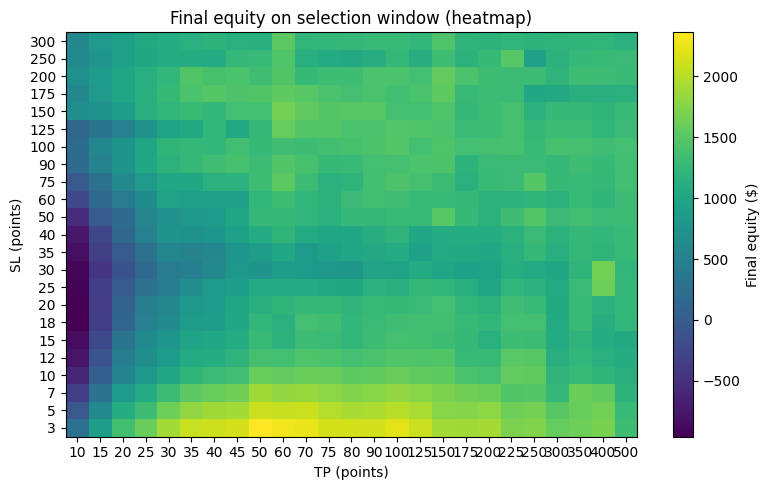

Max final equity grid cell: SL=3, TP=50 -> $2362.93


In [46]:
# SL/TP grid (selection only; never raw_hold).
SL_values = [3, 5, 7, 10, 12, 15, 18, 20, 25, 30, 35, 40, 50, 60, 75, 90, 100, 125, 150, 175, 200, 250, 300]
TP_values = [10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 75, 80, 90, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400, 500]

results = np.empty((len(SL_values), len(TP_values)))
for i, sl in enumerate(SL_values):
    for j, tp in enumerate(TP_values):
        eq = trading_backtest(
            raw_sel, sel_opens, sel_highs, sel_lows, sel_closes,
            "selection SL/TP grid (silent)",
            SL_POINTS=float(sl), TP_POINTS=float(tp), verbose=False,
        )
        results[i, j] = eq[-1]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(results, aspect="auto", origin="lower")
ax.set_xticks(range(len(TP_values)), labels=[str(x) for x in TP_values])
ax.set_yticks(range(len(SL_values)), labels=[str(x) for x in SL_values])
ax.set_xlabel("TP (points)")
ax.set_ylabel("SL (points)")
ax.set_title("Final equity on selection window (heatmap)")
plt.colorbar(im, ax=ax, label="Final equity ($)")
plt.tight_layout()
plt.show()

best_flat = np.nanargmax(results)
bi, bj = np.unravel_index(best_flat, results.shape)
print(f"Max final equity grid cell: SL={SL_values[bi]}, TP={TP_values[bj]} -> ${results[bi, bj]:.2f}")


**Backtest final (seleção + holdout)**

Define `BEST_SL` e `BEST_TP` **após** veres o heatmap; recalcula a curva de seleção e corre o holdout **uma vez** com os mesmos valores.


In [47]:
# Preencher após heatmap (evita correr holdout antes de escolheres SL/TP).
BEST_SL = 3.0  # preencher após heatmap
BEST_TP = 50.0  # preencher após heatmap

equities_selection = trading_backtest(
    raw_sel, sel_opens, sel_highs, sel_lows, sel_closes,
    "selection [train_end:val_end]",
    SL_POINTS=BEST_SL, TP_POINTS=BEST_TP,
    verbose=True,
)
equities_holdout = trading_backtest(
    raw_hold, ho_opens, ho_highs, ho_lows, ho_closes,
    "HOLDOUT FINAL",
    SL_POINTS=BEST_SL, TP_POINTS=BEST_TP,
    verbose=True,
)


===== selection [train_end:val_end] =====
Entries: 742 | Completed: 742
Longs: 654 | Shorts: 88
SL hits: 583 | TP hits: 158
Win rate: 21.4% | Avg PnL/trade: $2.39
Total fees: $816.20
Final equity: $2362.93
===== HOLDOUT FINAL =====
Entries: 3353 | Completed: 3353
Longs: 2776 | Shorts: 577
SL hits: 2736 | TP hits: 616
Win rate: 18.4% | Avg PnL/trade: $1.50
Total fees: $3688.30
Final equity: $4200.06


Result: Equity: 4200, Sharpe Ratio 0.0578, Drawdown 6.05%


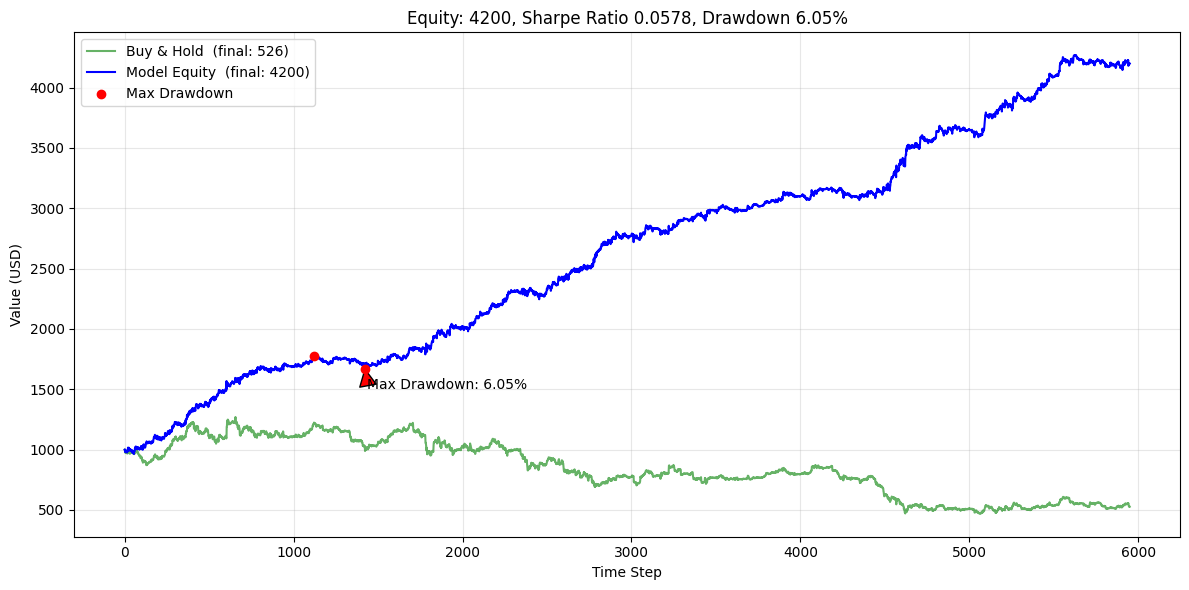

In [48]:
# Calculate max drawdown
def calculate_max_drawdown(equities):
    # Convert to numpy array for vectorized operations
    equity = np.array(equities)

    # Calculate cumulative maximum (peak equity)
    peak = np.maximum.accumulate(equity)

    # Drawdown: (Peak - Current) / Peak
    drawdown = (peak - equity) / peak

    # Index of maximum drawdown
    max_dd_idx = np.argmax(drawdown)

    # Find the peak before the maximum drawdown
    peak_idx = np.argmax(equity[:max_dd_idx + 1])

    return {
        "max_drawdown": drawdown[max_dd_idx],
        "peak_index": peak_idx,
        "trough_index": max_dd_idx,
        "peak_value": equity[peak_idx],
        "trough_value": equity[max_dd_idx]
    }

# Calculate Sharpe Ratio
def calculate_sharpe_ratio(equities):
    # Step 1: Compute 15-minute returns
    returns = []
    for i in range(1, len(equities)):
        ret = (equities[i] - equities[i-1]) / equities[i-1]
        returns.append(ret)

    # Step 2: Mean return
    mean_return = np.mean(returns)

    # Step 3: Standard deviation
    std_dev = np.std(returns, ddof=1)

    # Step 4: Sharpe Ratio (assuming risk-free rate = 0)
    sharpe_ratio = mean_return / std_dev

    sharpe_ratio = round(sharpe_ratio, 4)
    return sharpe_ratio


def plot_equity(backtest_opens, equities, result, sharpe_ratio):
    chart_title = f"Equity: {equities[-1]:.0f}, Sharpe Ratio {sharpe_ratio:.4f}, Drawdown {result['max_drawdown']:.2%}"
    print(f"Result: {chart_title}")

    # Buy & hold: investe pos_size no primeiro close e acompanha ate ao fim
    pos_size = 1000.0
    prices = np.array(backtest_opens[:len(equities)])
    buy_and_hold = pos_size * (prices / prices[0])

    fig, ax = plt.subplots(figsize=(12, 6))

    # Buy & hold
    ax.plot(
        buy_and_hold,
        color="green",
        alpha=0.6,
        lw=1.5,
        label=f"Buy & Hold  (final: {buy_and_hold[-1]:.0f})"
    )

    # Equity do modelo
    ax.plot(
        equities,
        color="blue",
        lw=1.5,
        label=f"Model Equity  (final: {equities[-1]:.0f})"
    )

    # Max drawdown
    ax.scatter(
        [result["peak_index"], result["trough_index"]],
        [result["peak_value"], result["trough_value"]],
        color="red", zorder=5, label="Max Drawdown"
    )
    ax.annotate(
        f"Max Drawdown: {result['max_drawdown']:.2%}",
        xy=(result["trough_index"], result["trough_value"]),
        xytext=(result["trough_index"] + 10, result["trough_value"] * 0.9),
        arrowprops=dict(facecolor="red", shrink=0.05),
    )

    ax.set_title(chart_title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value (USD)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig(chart_title.replace('%', '')+'.png', dpi=300)
# Curva do holdout (fora da amostra); tens também `equities_selection` se quiseres comparar
equities = equities_holdout
backtest_opens = ho_opens

# Calculate sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(equities)

# Calculate Max DD
result = calculate_max_drawdown(equities)

# Generate the plot
plot_equity(backtest_opens, equities, result, sharpe_ratio)